# 21. Validacion externa del refiner en otra escena

Este notebook valida el modulo de refinamiento de profundidad fuera de la escena usada para entrenarlo. El checkpoint se entreno en scene-0061_first30 y aqui se evalua congelado sobre scene-0103_first10, sin reentrenamiento ni ajuste adicional.

La validacion cubre cuatro niveles:

1. Error de profundidad frente a la proyeccion sparse de LIDAR_TOP.
2. Calidad geometrica de la pseudo-LiDAR frente a LIDAR_TOP.
3. Registro par a par entre frames consecutivos.
4. Trayectoria acumulada en una secuencia externa de 10 frames.

Esta prueba no elimina por completo el riesgo de sobreajuste, pero si reduce una limitacion importante: ya no se reporta el refiner solo sobre la misma escena usada para entrenar.


In [1]:

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML


CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name == 'notebooks' else CWD
TRAIN_SCENE = 'scene-0061_first30'
VAL_SCENE = 'scene-0103_first10'

CHECKPOINT = ROOT / 'outputs/scene-0061/depth_refinement_dataset_first30/refiner_training_rgb/best_depth_refiner.pt'
DATASET_DIR = ROOT / 'outputs/scene-0103/depth_refinement_dataset_first10'
PSEUDOLIDAR_DIR = ROOT / 'outputs/scene-0103/refined_pseudolidar_rgb_first10'

DEPTH_EVAL = DATASET_DIR / 'external_refiner_eval_rgb_scene0061_ckpt/external_depth_eval_summary.json'
PSEUDO_3D = PSEUDOLIDAR_DIR / 'refined_pseudolidar_comparison.json'
PAIRWISE_BASE = PSEUDOLIDAR_DIR / 'depth_pro/pairwise_registration_refined_metrics.json'
PAIRWISE_REFINED = PSEUDOLIDAR_DIR / 'refined/pairwise_registration_refined_metrics.json'
TRAJ_BASE = PSEUDOLIDAR_DIR / 'depth_pro/accumulated_trajectory_comparison.json'
TRAJ_REFINED = PSEUDOLIDAR_DIR / 'refined/accumulated_trajectory_comparison.json'

paths = {
    'checkpoint': CHECKPOINT,
    'dataset': DATASET_DIR / 'dataset_index.json',
    'depth_eval': DEPTH_EVAL,
    'pseudo_3d': PSEUDO_3D,
    'pairwise_base': PAIRWISE_BASE,
    'pairwise_refined': PAIRWISE_REFINED,
    'trajectory_base': TRAJ_BASE,
    'trajectory_refined': TRAJ_REFINED,
}
for name, path in paths.items():
    shown = path.relative_to(ROOT) if path.exists() else path
    print(f'{name:18s}: {path.exists()}  {shown}')


def display_table(rows, formats=None):
    formats = formats or {}
    if not rows:
        display(HTML('<em>Sin datos</em>'))
        return
    headers = list(rows[0].keys())
    html = ['<table>']
    html.append('<thead><tr>' + ''.join(f'<th>{h}</th>' for h in headers) + '</tr></thead>')
    html.append('<tbody>')
    for row in rows:
        tds = []
        for h in headers:
            value = row[h]
            fmt = formats.get(h)
            if fmt and isinstance(value, (int, float, np.integer, np.floating)):
                text = fmt.format(value)
            else:
                text = str(value)
            tds.append(f'<td>{text}</td>')
        html.append('<tr>' + ''.join(tds) + '</tr>')
    html.append('</tbody></table>')
    display(HTML(''.join(html)))


checkpoint        : True  outputs/scene-0061/depth_refinement_dataset_first30/refiner_training_rgb/best_depth_refiner.pt
dataset           : True  outputs/scene-0103/depth_refinement_dataset_first10/dataset_index.json
depth_eval        : True  outputs/scene-0103/depth_refinement_dataset_first10/external_refiner_eval_rgb_scene0061_ckpt/external_depth_eval_summary.json
pseudo_3d         : True  outputs/scene-0103/refined_pseudolidar_rgb_first10/refined_pseudolidar_comparison.json
pairwise_base     : True  outputs/scene-0103/refined_pseudolidar_rgb_first10/depth_pro/pairwise_registration_refined_metrics.json
pairwise_refined  : True  outputs/scene-0103/refined_pseudolidar_rgb_first10/refined/pairwise_registration_refined_metrics.json
trajectory_base   : True  outputs/scene-0103/refined_pseudolidar_rgb_first10/depth_pro/accumulated_trajectory_comparison.json
trajectory_refined: True  outputs/scene-0103/refined_pseudolidar_rgb_first10/refined/accumulated_trajectory_comparison.json


## Ejecucion realizada

La escena externa se preparo con 10 samples y las 6 camaras por sample, dando 60 entradas camara-frame. El checkpoint de scene-0061_first30 se aplico directamente sobre scene-0103_first10.

Comandos equivalentes para reproducir la validacion:




## 1. Validacion de profundidad sparse

In [2]:

depth_eval = json.loads(DEPTH_EVAL.read_text(encoding='utf-8'))

depth_rows = [
    {
        'metodo': 'Depth Pro base',
        'MAE sparse [m]': depth_eval['depth_pro']['mae_m'],
        'RMSE sparse [m]': depth_eval['depth_pro']['rmse_m'],
        'pixeles LiDAR validos': depth_eval['depth_pro']['valid_pixels'],
    },
    {
        'metodo': 'Depth Pro + RGB refinada',
        'MAE sparse [m]': depth_eval['refined']['mae_m'],
        'RMSE sparse [m]': depth_eval['refined']['rmse_m'],
        'pixeles LiDAR validos': depth_eval['refined']['valid_pixels'],
    },
]

display_table(depth_rows, {
    'MAE sparse [m]': '{:.3f}',
    'RMSE sparse [m]': '{:.3f}',
    'pixeles LiDAR validos': '{:,.0f}',
})

print(f"Mejora MAE:  {depth_eval['delta']['mae_m']:.3f} m ({depth_eval['delta']['mae_relative_pct']:.1f}%)")
print(f"Mejora RMSE: {depth_eval['delta']['rmse_m']:.3f} m ({depth_eval['delta']['rmse_relative_pct']:.1f}%)")
print(f"Dispositivo usado: {depth_eval['device']}")


metodo,MAE sparse [m],RMSE sparse [m],pixeles LiDAR validos
Depth Pro base,3.187,6.173,"184,375"
Depth Pro + RGB refinada,3.024,5.700,"184,375"


Mejora MAE:  -0.163 m (-5.1%)
Mejora RMSE: -0.472 m (-7.7%)
Dispositivo usado: cuda


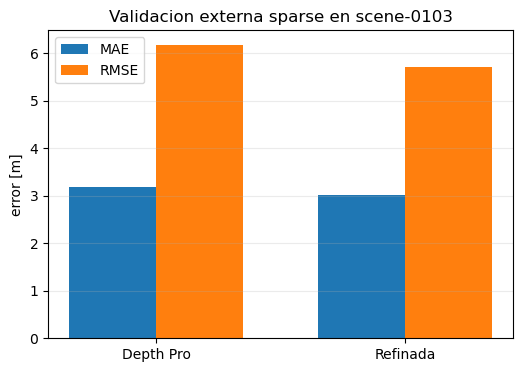

In [3]:

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(2)
width = 0.35
mae_values = [row['MAE sparse [m]'] for row in depth_rows]
rmse_values = [row['RMSE sparse [m]'] for row in depth_rows]
ax.bar(x - width/2, mae_values, width, label='MAE')
ax.bar(x + width/2, rmse_values, width, label='RMSE')
ax.set_xticks(x)
ax.set_xticklabels(['Depth Pro', 'Refinada'])
ax.set_ylabel('error [m]')
ax.set_title('Validacion externa sparse en scene-0103')
ax.grid(axis='y', alpha=0.25)
ax.legend()
plt.show()


## 2. Comparacion pseudo-LiDAR frente a LIDAR_TOP

In [4]:

pseudo_3d = json.loads(PSEUDO_3D.read_text(encoding='utf-8'))
agg3d = pseudo_3d['aggregate']

pseudo_rows = [
    {
        'metodo': 'Depth Pro base',
        'puntos pseudo medios': agg3d['depth_pro']['pseudo_points_mean'],
        'NN pseudo->LiDAR media [m]': agg3d['depth_pro']['pseudo_to_gt_mean_nn_mean'],
        'NN pseudo->LiDAR p95 [m]': agg3d['depth_pro']['pseudo_to_gt_p95_nn_mean'],
        'NN LiDAR->pseudo media [m]': agg3d['depth_pro']['gt_to_pseudo_mean_nn_mean'],
        'BEV IoU': agg3d['depth_pro']['bev_iou_mean'],
    },
    {
        'metodo': 'Depth Pro + RGB refinada',
        'puntos pseudo medios': agg3d['refined']['pseudo_points_mean'],
        'NN pseudo->LiDAR media [m]': agg3d['refined']['pseudo_to_gt_mean_nn_mean'],
        'NN pseudo->LiDAR p95 [m]': agg3d['refined']['pseudo_to_gt_p95_nn_mean'],
        'NN LiDAR->pseudo media [m]': agg3d['refined']['gt_to_pseudo_mean_nn_mean'],
        'BEV IoU': agg3d['refined']['bev_iou_mean'],
    },
]

display_table(pseudo_rows, {
    'puntos pseudo medios': '{:,.0f}',
    'NN pseudo->LiDAR media [m]': '{:.3f}',
    'NN pseudo->LiDAR p95 [m]': '{:.3f}',
    'NN LiDAR->pseudo media [m]': '{:.3f}',
    'BEV IoU': '{:.3f}',
})

nn_delta = pseudo_rows[1]['NN pseudo->LiDAR media [m]'] - pseudo_rows[0]['NN pseudo->LiDAR media [m]']
iou_delta = pseudo_rows[1]['BEV IoU'] - pseudo_rows[0]['BEV IoU']
print(f"Cambio NN pseudo->LiDAR medio: {nn_delta:.3f} m")
print(f"Cambio BEV IoU: {iou_delta:.3f}")


metodo,puntos pseudo medios,NN pseudo->LiDAR media [m],NN pseudo->LiDAR p95 [m],NN LiDAR->pseudo media [m],BEV IoU
Depth Pro base,"16,791",1.058,3.543,1.571,0.232
Depth Pro + RGB refinada,"21,422",0.975,2.924,1.430,0.225


Cambio NN pseudo->LiDAR medio: -0.084 m
Cambio BEV IoU: -0.008


## 3. Registro par a par en la escena externa

In [5]:

pair_base = json.loads(PAIRWISE_BASE.read_text(encoding='utf-8'))
pair_ref = json.loads(PAIRWISE_REFINED.read_text(encoding='utf-8'))

def pair_rows(label, data):
    agg = data['aggregate']
    return [
        {
            'nube': label,
            'registro': 'ICP directo',
            'traslacion media [m]': agg['pseudo_naive_translation_error_mean_m'],
            'rotacion media [deg]': agg['pseudo_naive_rotation_error_mean_deg'],
            'fitness medio': agg['pseudo_naive_fitness_mean'],
        },
        {
            'nube': label,
            'registro': 'ICP filtrado/multiescala',
            'traslacion media [m]': agg['pseudo_refined_translation_error_mean_m'],
            'rotacion media [deg]': agg['pseudo_refined_rotation_error_mean_deg'],
            'fitness medio': agg['pseudo_refined_fitness_mean'],
        },
    ]

pairwise_rows = pair_rows('Depth Pro base', pair_base) + pair_rows('Depth Pro + RGB refinada', pair_ref)

display_table(pairwise_rows, {
    'traslacion media [m]': '{:.3f}',
    'rotacion media [deg]': '{:.3f}',
    'fitness medio': '{:.3f}',
})


nube,registro,traslacion media [m],rotacion media [deg],fitness medio
Depth Pro base,ICP directo,2.525,1.822,0.760
Depth Pro base,ICP filtrado/multiescala,3.811,5.242,0.647
Depth Pro + RGB refinada,ICP directo,2.836,2.455,0.791
Depth Pro + RGB refinada,ICP filtrado/multiescala,4.166,3.129,0.733


## 4. Trayectoria acumulada externa

In [6]:

traj_base = json.loads(TRAJ_BASE.read_text(encoding='utf-8'))
traj_ref = json.loads(TRAJ_REFINED.read_text(encoding='utf-8'))
strategies = ['front_icp_only', 'front_baseline_cfg05', 'front_narrow_cfg05']
labels = {
    'front_icp_only': 'front ICP',
    'front_baseline_cfg05': 'front cfg05',
    'front_narrow_cfg05': 'front narrow cfg05',
}

traj_rows = []
for strategy in strategies:
    for method, data in [('Depth Pro base', traj_base), ('Depth Pro + RGB refinada', traj_ref)]:
        agg = data['trajectories'][strategy]['aggregate']
        traj_rows.append({
            'estrategia': labels[strategy],
            'metodo': method,
            'traslacion final [m]': agg['final_translation_error_m'],
            'rotacion final [deg]': agg['final_rotation_error_deg'],
            'traslacion media [m]': agg['mean_translation_error_m'],
            'rotacion media [deg]': agg['mean_rotation_error_deg'],
            'frames': agg['num_frames'],
        })

display_table(traj_rows, {
    'traslacion final [m]': '{:.3f}',
    'rotacion final [deg]': '{:.3f}',
    'traslacion media [m]': '{:.3f}',
    'rotacion media [deg]': '{:.3f}',
})


estrategia,metodo,traslacion final [m],rotacion final [deg],traslacion media [m],rotacion media [deg],frames
front ICP,Depth Pro base,27.005,5.295,16.137,4.402,10
front ICP,Depth Pro + RGB refinada,27.998,4.130,17.116,4.687,10
front cfg05,Depth Pro base,44.896,178.164,23.740,101.827,10
front cfg05,Depth Pro + RGB refinada,28.935,176.596,19.061,66.832,10
front narrow cfg05,Depth Pro base,28.763,6.297,16.432,7.730,10
front narrow cfg05,Depth Pro + RGB refinada,28.685,19.244,17.029,7.700,10


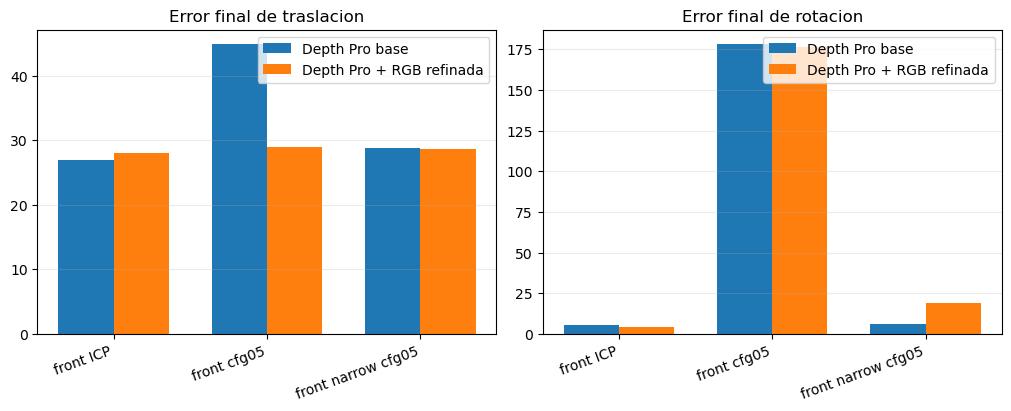

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
ordered_labels = [labels[s] for s in strategies]
methods = ['Depth Pro base', 'Depth Pro + RGB refinada']
colors = ['#1f77b4', '#ff7f0e']

for ax, metric, title in [
    (axes[0], 'traslacion final [m]', 'Error final de traslacion'),
    (axes[1], 'rotacion final [deg]', 'Error final de rotacion'),
]:
    x = np.arange(len(ordered_labels))
    width = 0.36
    for offset, method, color in zip([-width/2, width/2], methods, colors):
        values = []
        for label in ordered_labels:
            value = next(row[metric] for row in traj_rows if row['estrategia'] == label and row['metodo'] == method)
            values.append(value)
        ax.bar(x + offset, values, width, label=method, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(ordered_labels, rotation=20, ha='right')
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.25)
    ax.legend(loc='best')
plt.show()


## 5. Visualizacion de la validacion externa

Se generan dos figuras en la carpeta de outputs de `scene-0103`:

- `external_validation_pointcloud_bev.png`: vista cenital de `LIDAR_TOP`, pseudo-LiDAR base y pseudo-LiDAR refinada para un frame intermedio de la escena externa.
- `external_validation_metrics_summary.png`: resumen visual de las metricas externas principales.

La vista de nubes usa un recorte espacial solo para que la figura sea legible. Las metricas anteriores se calculan sobre las nubes y mascaras completas usadas por los scripts de evaluacion.


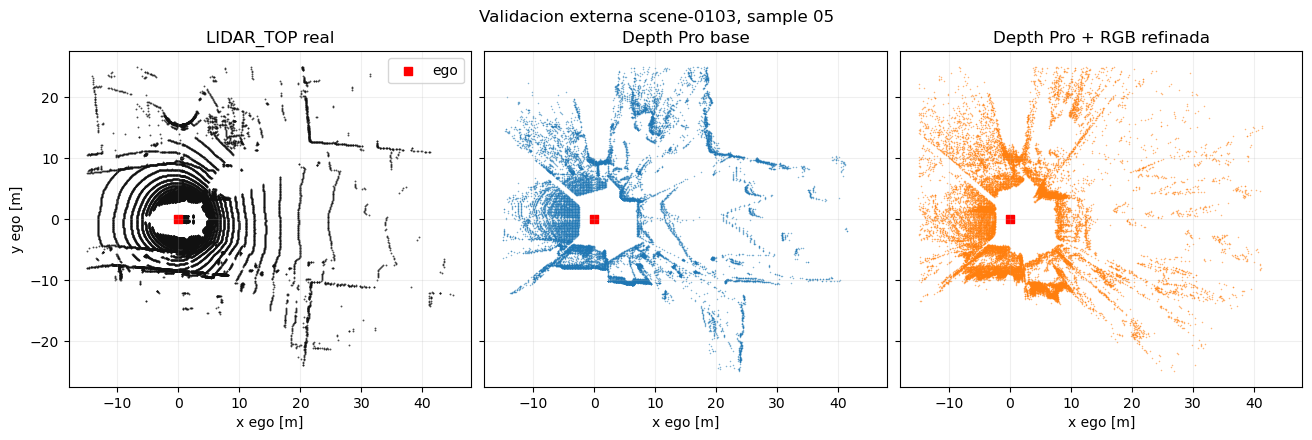

Figura guardada: outputs/scene-0103/refined_pseudolidar_rgb_first10/figures/external_validation_pointcloud_bev.png


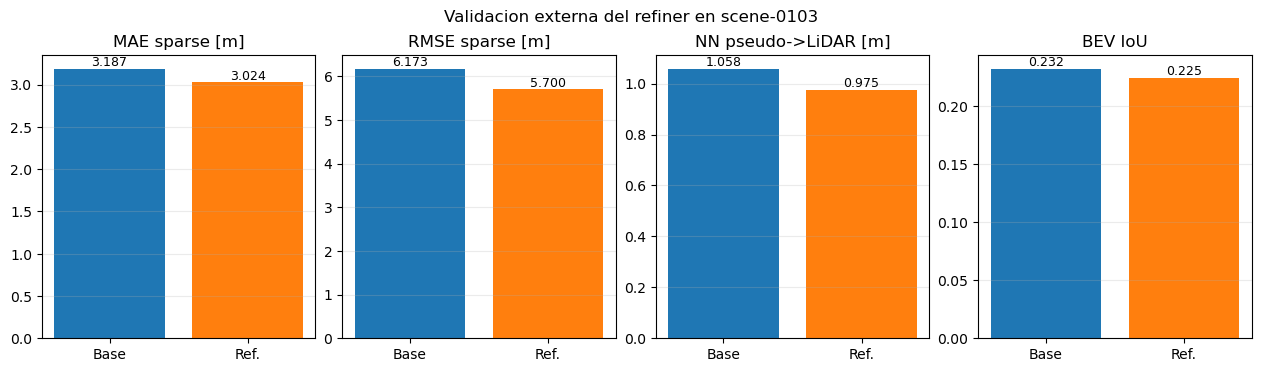

Figura guardada: outputs/scene-0103/refined_pseudolidar_rgb_first10/figures/external_validation_metrics_summary.png


In [8]:

from pathlib import Path
import numpy as np

FIGURES_DIR = PSEUDOLIDAR_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def load_ply_xyz(path):
    path = Path(path)
    with path.open('rb') as f:
        header_lines = []
        while True:
            line = f.readline()
            if not line:
                raise ValueError(f'PLY header not finished: {path}')
            header_lines.append(line.decode('ascii').strip())
            if line.strip() == b'end_header':
                break
        vertex_count = None
        properties = []
        in_vertex = False
        for line in header_lines:
            parts = line.split()
            if len(parts) >= 3 and parts[0] == 'element' and parts[1] == 'vertex':
                vertex_count = int(parts[2])
                in_vertex = True
                continue
            if len(parts) >= 2 and parts[0] == 'element' and parts[1] != 'vertex':
                in_vertex = False
            if in_vertex and len(parts) == 3 and parts[0] == 'property':
                properties.append((parts[1], parts[2]))
        if vertex_count is None:
            raise ValueError(f'No vertex count in PLY: {path}')
        dtype_map = {
            'double': '<f8',
            'float': '<f4',
            'uchar': 'u1',
            'uint8': 'u1',
            'char': 'i1',
            'int': '<i4',
            'uint': '<u4',
        }
        dtype = np.dtype([(name, dtype_map[prop_type]) for prop_type, name in properties])
        data = np.fromfile(f, dtype=dtype, count=vertex_count)
    return np.column_stack([data['x'], data['y'], data['z']]).astype(np.float32)


def crop_for_bev(points):
    x, y, z = points[:, 0], points[:, 1], points[:, 2]
    mask = (x >= -15) & (x <= 45) & (y >= -25) & (y <= 25) & (z >= -3) & (z <= 4)
    return points[mask]


def deterministic_subsample(points, max_points=35000):
    if len(points) <= max_points:
        return points
    idx = np.linspace(0, len(points) - 1, max_points).astype(int)
    return points[idx]

base_summary = json.loads((PSEUDOLIDAR_DIR / 'depth_pro/run_summary.json').read_text(encoding='utf-8'))
ref_summary = json.loads((PSEUDOLIDAR_DIR / 'refined/run_summary.json').read_text(encoding='utf-8'))
base_samples = sorted(base_summary['samples'], key=lambda item: item['index'])
ref_samples = sorted(ref_summary['samples'], key=lambda item: item['index'])
sample_pos = len(base_samples) // 2
base_sample = base_samples[sample_pos]
ref_sample = ref_samples[sample_pos]

lidar_xyz = deterministic_subsample(crop_for_bev(load_ply_xyz(base_sample['lidar_path'])))
base_xyz = deterministic_subsample(crop_for_bev(load_ply_xyz(base_sample['pseudo_path'])))
refined_xyz = deterministic_subsample(crop_for_bev(load_ply_xyz(ref_sample['pseudo_path'])))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True, sharex=True, sharey=True)
panels = [
    ('LIDAR_TOP real', lidar_xyz, '#111111', 1.8, 0.75),
    ('Depth Pro base', base_xyz, '#1f77b4', 1.2, 0.55),
    ('Depth Pro + RGB refinada', refined_xyz, '#ff7f0e', 1.2, 0.55),
]
for ax, (title, xyz, color, size, alpha) in zip(axes, panels):
    ax.scatter(xyz[:, 0], xyz[:, 1], s=size, c=color, alpha=alpha, linewidths=0)
    ax.scatter([0], [0], marker='s', s=35, c='red', label='ego')
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.2)
    ax.set_xlabel('x ego [m]')
axes[0].set_ylabel('y ego [m]')
axes[0].legend(loc='upper right')
fig.suptitle('Validacion externa scene-0103, sample %02d' % base_sample['index'])
pointcloud_fig = FIGURES_DIR / 'external_validation_pointcloud_bev.png'
fig.savefig(pointcloud_fig, dpi=180, bbox_inches='tight')
plt.show()
print('Figura guardada:', pointcloud_fig.relative_to(ROOT))

# Metric summary figure.
depth_eval = json.loads(DEPTH_EVAL.read_text(encoding='utf-8'))
pseudo_3d = json.loads(PSEUDO_3D.read_text(encoding='utf-8'))
agg3d = pseudo_3d['aggregate']
metric_panels = [
    ('MAE sparse [m]', depth_eval['depth_pro']['mae_m'], depth_eval['refined']['mae_m']),
    ('RMSE sparse [m]', depth_eval['depth_pro']['rmse_m'], depth_eval['refined']['rmse_m']),
    ('NN pseudo->LiDAR [m]', agg3d['depth_pro']['pseudo_to_gt_mean_nn_mean'], agg3d['refined']['pseudo_to_gt_mean_nn_mean']),
    ('BEV IoU', agg3d['depth_pro']['bev_iou_mean'], agg3d['refined']['bev_iou_mean']),
]
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.6), constrained_layout=True)
for ax, (title, base_value, refined_value) in zip(axes, metric_panels):
    ax.bar([0, 1], [base_value, refined_value], color=['#1f77b4', '#ff7f0e'])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Base', 'Ref.'])
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.25)
    for x_pos, value in enumerate([base_value, refined_value]):
        ax.text(x_pos, value, f'{value:.3f}', ha='center', va='bottom', fontsize=9)
fig.suptitle('Validacion externa del refiner en scene-0103')
metrics_fig = FIGURES_DIR / 'external_validation_metrics_summary.png'
fig.savefig(metrics_fig, dpi=180, bbox_inches='tight')
plt.show()
print('Figura guardada:', metrics_fig.relative_to(ROOT))


## Conclusiones de la validacion externa

En scene-0103_first10, el refiner entrenado en scene-0061_first30 si generaliza parcialmente en la metrica de profundidad sparse: reduce el MAE de 3.19 m a 3.02 m y el RMSE de 6.17 m a 5.70 m. La mejora es moderada, pero relevante porque la escena no se uso para entrenar.

La mejora tambien aparece en parte de la comparacion geometrica 3D: la distancia media pseudo->LiDAR baja de 1.06 m a 0.97 m y el percentil 95 mejora de 3.54 m a 2.92 m. Sin embargo, la BEV IoU baja ligeramente de 0.232 a 0.225, por lo que el refinamiento no mejora todas las metricas espaciales.

En registro temporal la conclusion es mas conservadora. Sobre esta escena externa, el refinamiento no mejora de forma robusta el error de pose par a par; con las estrategias evaluadas, la traslacion media y la rotacion media pueden empeorar respecto a Depth Pro base. Esto refuerza la conclusion principal del TFM: mejorar la profundidad y la nube 3D no garantiza automaticamente una odometria acumulada mas estable.

En trayectoria acumulada, el caso ront_baseline_cfg05 mejora la traslacion final al pasar de 44.90 m a 28.93 m, pero la rotacion sigue siendo muy alta en ambos casos. En ront_icp_only, la rotacion final mejora ligeramente, pero la traslacion final empeora un poco. Por tanto, esta validacion externa debe presentarse como evidencia de generalizacion parcial del refiner y, a la vez, como una limitacion clara para su uso directo en SLAM robusto.
